In [1]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
data_log2 = pd.read_pickle('data_log2_Lisbon_threshold.pkl')

In [3]:
data_log2

Protein.Group,A0A0A0MS15,A0A0C4DH38,O00391,O00462,O00533,O14498,O14594,O14773,O15031,O15394,...,Q9UBP4,Q9UBX1,Q9UBX5,Q9UGM5,Q9UHL4,Q9ULB1,Q9Y240,Q9Y4C0,Q9Y646,Q9Y6R7
LIS090,8.008485,7.884580,7.046524,4.877352,9.502615,6.808836,6.264486,6.706240,5.754602,8.666203,...,11.983824,7.474387,7.673846,6.288357,6.569209,8.519585,4.462792,8.721916,6.428503,9.765251
LIS098,8.408618,8.316675,6.742249,5.249123,9.214086,6.607503,5.651112,6.832662,6.195058,8.234889,...,11.609941,7.249929,7.780402,6.187722,6.248402,8.200359,4.626223,8.767165,6.877487,8.354624
LIS017,6.710379,7.121647,6.803782,5.281576,9.288289,6.816740,6.544420,6.978630,6.114546,8.426206,...,11.674201,7.640505,8.166806,5.968895,6.599523,8.233011,5.536920,8.527669,7.343052,7.835937
LIS026,8.605772,8.765760,7.234664,4.971061,9.194671,6.489169,6.035030,6.804389,5.470348,8.621330,...,11.564264,7.439665,8.143383,7.001780,6.322777,8.011177,4.982035,8.391046,6.702228,8.845537
LIS009,8.695162,8.731662,7.343248,4.763098,9.380682,6.913033,6.115934,6.661621,5.664136,8.492606,...,11.567961,7.399504,7.611748,7.179829,6.603539,7.870790,4.998123,8.460526,6.401837,9.694913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS096,8.944671,8.747877,6.899816,5.284466,9.197529,6.396685,7.142434,6.582059,5.887986,8.347488,...,11.364140,6.734005,7.813114,5.887223,6.989116,8.596130,4.606496,8.836341,6.434588,9.504585
LIS097,8.581528,7.769580,7.149879,4.566925,9.078714,7.260854,6.789195,5.965960,5.749282,7.980528,...,11.345755,7.420508,8.007846,6.271569,6.409046,8.521522,4.588019,8.792074,6.873395,9.545036
LIS102,8.583207,7.473089,7.144108,4.763582,9.710235,7.141964,7.286142,6.577400,5.992549,8.624346,...,11.306529,7.106997,7.976610,6.025791,6.078200,8.961421,4.840297,9.106806,6.697260,9.566731
LIS103,8.504410,9.427137,6.745062,4.590740,8.539744,7.318733,5.619750,6.116679,5.785435,8.008053,...,10.799476,7.207493,7.716394,6.032231,5.496488,8.011059,4.539847,8.241826,6.325904,10.136773


In [4]:
import pickle

with open('list_groups.pkl', 'rb') as f:
    list_groups = pickle.load(f)

print(len(list_groups))

64


In [5]:
list_groups = pd.Series(list_groups)

In [6]:
def calculate_vip(pls, X):
    
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_
    
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    
    Wnorm = (w ** 2) / np.sum(w ** 2, axis=0)
    
    vip = np.sqrt(p * (Wnorm @ s) / np.sum(s))
    
    return vip.flatten()

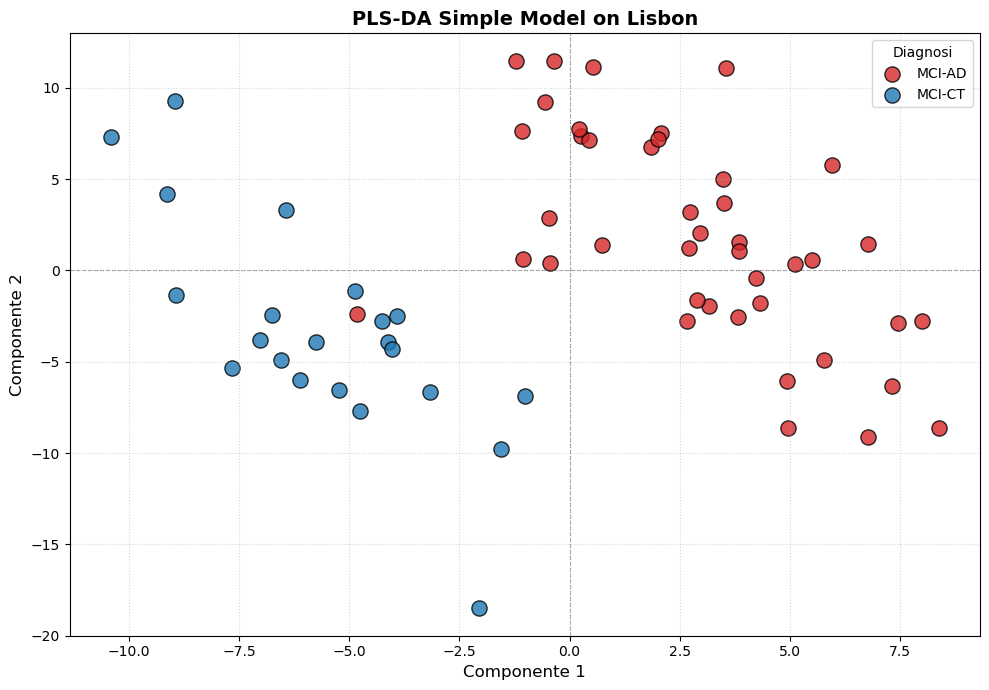

--- RISULTATI MODELLO SEMPLICE ---
MCC: 0.9663
Accuratezza: 98.44%


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import matthews_corrcoef

# ==========================================
# 1. SETUP DATI
# ==========================================
X = data_log2.copy()
y = np.array(list_groups)

# Fit e Transform per gestire le etichette
le = LabelEncoder()
y_encoded = le.fit_transform(y) 

# ==========================================
# 2. CALCOLO PLS-DA SEMPLICE
# ==========================================
pls = PLSRegression(n_components=2)
pls.fit(X, y_encoded)

# Otteniamo gli Scores per il plot
scores = pls.x_scores_

# Previsioni per il calcolo delle metriche
# Il PLS restituisce valori continui, usiamo 0.5 come soglia di decisione
y_prob = pls.predict(X).ravel()
y_pred = (y_prob > 0.5).astype(int)

# Calcolo MCC
mcc_value = matthews_corrcoef(y_encoded, y_pred)

# ==========================================
# 3. PLOT DELLA DIVISIONE
# ==========================================
plt.figure(figsize=(10, 7))
colors_map = {'MCI-AD': '#d62728', 'MCI-CT': '#1f77b4'}

for label in le.classes_:
    mask = (y == label)
    plt.scatter(
        scores[mask, 0], 
        scores[mask, 1], 
        label=label, 
        s=120, alpha=0.8, edgecolors='k', linewidth=1,
        c=colors_map.get(label, 'gray')
    )

# Aggiungiamo l'MCC direttamente nel titolo per averlo sott'occhio
plt.title('PLS-DA Simple Model on Lisbon', 
          fontsize=14, fontweight='bold')

plt.xlabel('Componente 1', fontsize=12)
plt.ylabel('Componente 2', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title="Diagnosi", frameon=True)
plt.savefig('easy_plsda_on_Lisbon')
plt.tight_layout()
plt.show()

# ==========================================
# 4. REPORT FINALE
# ==========================================
print(f"--- RISULTATI MODELLO SEMPLICE ---")
print(f"MCC: {mcc_value:.4f}")
print(f"Accuratezza: {np.mean(y_pred == y_encoded):.2%}")

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder

# ======================
# DATA LOADING
# ======================
X = data_log2
y = np.array(list_groups)

# ======================
# GLOBAL PARAMETERS
# ======================
vip_thresholds = [0.1, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
decision_thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

n_iterations = 50  
n_seeds = 15       

all_test_mcc = []
all_test_auc = []
all_n_features = []
all_best_vip_thr = []
all_best_dec_thr = []
global_stable_counts = pd.Series(0, index=X.columns)

def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]
    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)
    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)
    return X.iloc[indices], y[indices]

# ======================
# MAIN SEED LOOP
# ======================
for seed in range(n_seeds):
    print(f"\n" + "="*40)
    print(f"RUNNING SEED {seed}")
    print("="*40)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=seed
    )

    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=seed)
    le = LabelEncoder()
    le.fit(y_train)
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)

    # Griglia per ottimizzazione incrociata (VIP x Decision)
    grid_mcc = np.zeros((len(vip_thresholds), len(decision_thresholds)))
    grid_auc = np.zeros(len(vip_thresholds))

    for v_idx, v_thr in enumerate(vip_thresholds):
        fold_mccs = []
        fold_aucs = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_sub, y_sub = X_train.iloc[train_idx], y_train[train_idx]
            X_val, y_val = X_train.iloc[val_idx], y_train[val_idx]
            y_val_enc = le.transform(y_val)

            # --- Feature Selection (VIP Stability) ---
            vip_matrix = np.zeros((n_iterations, X_sub.shape[1]))
            for i in range(n_iterations):
                X_b, y_b = stratified_bootstrap(X_sub, y_sub)
                pls_b = PLSRegression(n_components=2)
                pls_b.fit(X_b, le.transform(y_b))
                vip_matrix[i] = (calculate_vip(pls_b, X_b) > 1).astype(int)

            vip_freq = vip_matrix.mean(axis=0)
            sel_feats = X_sub.columns[vip_freq >= v_thr]
            if len(sel_feats) == 0: sel_feats = [X_sub.columns[np.argmax(vip_freq)]]

            # --- Validation ---
            pls_cv = PLSRegression(n_components=2)
            pls_cv.fit(X_sub[sel_feats], le.transform(y_sub))
            y_prob_val = pls_cv.predict(X_val[sel_feats]).ravel()

            mccs_per_dec = [matthews_corrcoef(y_val_enc, (y_prob_val > d_thr).astype(int)) for d_thr in decision_thresholds]
            fold_mccs.append(mccs_per_dec)
            fold_aucs.append(roc_auc_score(y_val_enc, y_prob_val))

        grid_mcc[v_idx, :] = np.mean(fold_mccs, axis=0)
        grid_auc[v_idx] = np.mean(fold_aucs)

    # Identificazione best combination
    best_v_idx, best_d_idx = np.unravel_index(np.argmax(grid_mcc), grid_mcc.shape)
    best_v_thr = vip_thresholds[best_v_idx]
    best_d_thr = decision_thresholds[best_d_idx]

    # --- Training Finale (Full X_train) ---
    final_vip_matrix = np.zeros((n_iterations, X_train.shape[1]))
    for i in range(n_iterations):
        X_b, y_b = stratified_bootstrap(X_train, y_train)
        pls_b = PLSRegression(n_components=2).fit(X_b, le.transform(y_b))
        final_vip_matrix[i] = (calculate_vip(pls_b, X_b) > 1).astype(int)
    
    final_vip_freq = final_vip_matrix.mean(axis=0)
    top_features = X_train.columns[final_vip_freq >= best_v_thr]
    if len(top_features) == 0: top_features = [X_train.columns[np.argmax(final_vip_freq)]]

    global_stable_counts.loc[top_features] += 1

    # --- Test Finale (X_test) ---
    pls_final = PLSRegression(n_components=2).fit(X_train[top_features], y_train_enc)
    y_prob_test = pls_final.predict(X_test[top_features]).ravel()
    
    test_mcc = matthews_corrcoef(y_test_enc, (y_prob_test > best_d_thr).astype(int))
    test_auc = roc_auc_score(y_test_enc, y_prob_test)

    all_test_mcc.append(test_mcc)
    all_test_auc.append(test_auc)
    all_n_features.append(len(top_features))
    all_best_vip_thr.append(best_v_thr)
    all_best_dec_thr.append(best_d_thr)

    print(f"Seed {seed}: MCC={test_mcc:.3f}, AUC={test_auc:.3f}, Features={len(top_features)}")

# ======================
# FINAL PERFORMANCE SUMMARY
# ======================
print("\n" + "="*50)
print("FINAL CONSOLIDATED RESULTS (30 SEEDS)")
print("="*50)
print(f"Mean MCC: {np.mean(all_test_mcc):.4f} (±{np.std(all_test_mcc):.4f})")
print(f"Mean AUC: {np.mean(all_test_auc):.4f} (±{np.std(all_test_auc):.4f})")
print(f"Mean Features: {np.mean(all_n_features):.2f} (±{np.std(all_n_features):.2f})")

print("\n--- TOP 30 MOST STABLE PROTEINS ACROSS SEEDS ---")
global_stability = (global_stable_counts / n_seeds).sort_values(ascending=False)
print(global_stability)

print("\n--- FREQUENCY OF SELECTED VIP THRESHOLDS (Stability) ---")
print(pd.Series(all_best_vip_thr).value_counts(normalize=True).sort_index())

# ======================
# BUILD RESULT TABLE (PLS-DA)
# ======================
df_plsda = pd.DataFrame({
    "model": "PLS-DA",
    "seed": list(range(n_seeds)),
    "mcc": all_test_mcc,
    "auc": all_test_auc,
    "n_features": all_n_features,
    "best_vip_threshold": all_best_vip_thr,
    "best_decision_threshold": all_best_dec_thr
})

print("\n--- PLS-DA RESULTS TABLE ---")
print(df_plsda.head())

print("\n--- FREQUENCY OF SELECTED DECISION THRESHOLDS (Classification) ---")
print(pd.Series(all_best_dec_thr).value_counts(normalize=True).sort_index())


RUNNING SEED 0
Seed 0: MCC=0.734, AUC=0.956, Features=181

RUNNING SEED 1
Seed 1: MCC=0.811, AUC=0.956, Features=197

RUNNING SEED 2
Seed 2: MCC=1.000, AUC=1.000, Features=190

RUNNING SEED 3
Seed 3: MCC=0.899, AUC=0.945, Features=21

RUNNING SEED 4
Seed 4: MCC=0.780, AUC=0.945, Features=42

RUNNING SEED 5
Seed 5: MCC=0.899, AUC=0.989, Features=188

RUNNING SEED 6
Seed 6: MCC=1.000, AUC=1.000, Features=210

RUNNING SEED 7
Seed 7: MCC=1.000, AUC=1.000, Features=72

RUNNING SEED 8
Seed 8: MCC=1.000, AUC=1.000, Features=186

RUNNING SEED 9
Seed 9: MCC=0.899, AUC=0.967, Features=46

RUNNING SEED 10
Seed 10: MCC=0.780, AUC=0.934, Features=29

RUNNING SEED 11
Seed 11: MCC=0.787, AUC=0.923, Features=6

RUNNING SEED 12
Seed 12: MCC=0.685, AUC=0.967, Features=185

RUNNING SEED 13
Seed 13: MCC=1.000, AUC=1.000, Features=94

RUNNING SEED 14
Seed 14: MCC=0.899, AUC=0.956, Features=86

FINAL CONSOLIDATED RESULTS (30 SEEDS)
Mean MCC: 0.8781 (±0.1053)
Mean AUC: 0.9692 (±0.0261)
Mean Features: 115.53

In [9]:
print(len(global_stability))
global_stability.to_pickle('global_stable_counts_Lisbon_threshold.pkl')
df_plsda.to_pickle('df_plsda_Lisbon_threshold.pkl')

255


In [10]:
global_stability.tail(10)

Protein.Group
Q96S96    0.066667
P01619    0.066667
P23468    0.066667
P01860    0.066667
P05452    0.066667
P09417    0.066667
Q13228    0.000000
P98160    0.000000
Q92876    0.000000
P05090    0.000000
dtype: float64

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder

# ======================
# DATA
# ======================
X = data_log2
y = np.array(list_groups)

# ======================
# PARAMETERS
# ======================
vip_thresholds = [0.1, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
decision_thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

n_iterations = 50
n_splits = 5

# ======================
# ENCODING
# ======================
le = LabelEncoder()
y_enc = le.fit_transform(y)

# ======================
# STRATIFIED BOOTSTRAP
# ======================
def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]
    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)
    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)
    return X.iloc[indices], y[indices]

# ======================
# CV
# ======================
cv = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.3, random_state=42)

grid_mcc = np.zeros((len(vip_thresholds), len(decision_thresholds)))
grid_auc = np.zeros(len(vip_thresholds))

# 👉 per salvare metriche fold-level della best combo
all_val_mcc = []
all_val_auc = []

# 👉 conteggio globale VIP>1 (VERO, non threshold-based)
vip_global_counts = np.zeros(X.shape[1])
vip_global_total = 0

for v_idx, v_thr in enumerate(vip_thresholds):
    fold_mccs = []
    fold_aucs = []

    for train_idx, val_idx in cv.split(X, y):
        X_sub, y_sub = X.iloc[train_idx], y[train_idx]
        X_val, y_val = X.iloc[val_idx], y[val_idx]
        y_val_enc = le.transform(y_val)

        # ======================
        # VIP STABILITY
        # ======================
        vip_matrix = np.zeros((n_iterations, X_sub.shape[1]))

        for i in range(n_iterations):
            X_b, y_b = stratified_bootstrap(X_sub, y_sub)

            pls_b = PLSRegression(n_components=2)
            pls_b.fit(X_b, le.transform(y_b))

            vip_scores = calculate_vip(pls_b, X_b)

            # 👉 CONTEGGIO GLOBALE (indipendente da threshold)
            vip_global_counts += (vip_scores > 1).astype(int)
            vip_global_total += 1

            vip_matrix[i] = (vip_scores > 1).astype(int)

        vip_freq = vip_matrix.mean(axis=0)
        sel_feats = X_sub.columns[vip_freq >= v_thr]

        if len(sel_feats) == 0:
            sel_feats = [X_sub.columns[np.argmax(vip_freq)]]

        # ======================
        # VALIDATION
        # ======================
        pls_cv = PLSRegression(n_components=2)
        pls_cv.fit(X_sub[sel_feats], le.transform(y_sub))

        y_prob_val = pls_cv.predict(X_val[sel_feats]).ravel()

        mccs_per_dec = [
            matthews_corrcoef(y_val_enc, (y_prob_val > d_thr).astype(int))
            for d_thr in decision_thresholds
        ]

        fold_mccs.append(mccs_per_dec)
        fold_aucs.append(roc_auc_score(y_val_enc, y_prob_val))

    grid_mcc[v_idx, :] = np.mean(fold_mccs, axis=0)
    grid_auc[v_idx] = np.mean(fold_aucs)

# ======================
# BEST PARAMS
# ======================
best_v_idx, best_d_idx = np.unravel_index(np.argmax(grid_mcc), grid_mcc.shape)
best_v_thr = vip_thresholds[best_v_idx]
best_d_thr = decision_thresholds[best_d_idx]

print(f"\nBest VIP threshold: {best_v_thr}")
print(f"Best decision threshold: {best_d_thr}")

# ======================
# RICALCOLO METRICHE SOLO PER BEST COMBO
# ======================
for train_idx, val_idx in cv.split(X, y):
    X_sub, y_sub = X.iloc[train_idx], y[train_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]
    y_val_enc = le.transform(y_val)

    vip_matrix = np.zeros((n_iterations, X_sub.shape[1]))

    for i in range(n_iterations):
        X_b, y_b = stratified_bootstrap(X_sub, y_sub)
        pls_b = PLSRegression(n_components=2)
        pls_b.fit(X_b, le.transform(y_b))
        vip_matrix[i] = (calculate_vip(pls_b, X_b) > 1).astype(int)

    vip_freq = vip_matrix.mean(axis=0)
    sel_feats = X_sub.columns[vip_freq >= best_v_thr]

    if len(sel_feats) == 0:
        sel_feats = [X_sub.columns[np.argmax(vip_freq)]]

    pls_cv = PLSRegression(n_components=2)
    pls_cv.fit(X_sub[sel_feats], le.transform(y_sub))

    y_prob_val = pls_cv.predict(X_val[sel_feats]).ravel()

    all_val_mcc.append(
        matthews_corrcoef(y_val_enc, (y_prob_val > best_d_thr).astype(int))
    )
    all_val_auc.append(
        roc_auc_score(y_val_enc, y_prob_val)
    )

# ======================
# METRICHE FINALI
# ======================
print("\n=== VALIDATION PERFORMANCE ===")
print(f"MCC: {np.mean(all_val_mcc):.4f} ± {np.std(all_val_mcc):.4f}")
print(f"AUC: {np.mean(all_val_auc):.4f} ± {np.std(all_val_auc):.4f}")

# ======================
# VIP GLOBAL FREQUENCY
# ======================
vip_global_freq = vip_global_counts / vip_global_total
vip_global_series = pd.Series(vip_global_freq, index=X.columns).sort_values(ascending=False)

print("\n=== VIP > 1 GLOBAL FREQUENCY ===")
print(vip_global_series)


Best VIP threshold: 0.1
Best decision threshold: 0.5

=== VALIDATION PERFORMANCE ===
MCC: 0.9155 ± 0.0814
AUC: 0.9648 ± 0.0329

=== VIP > 1 GLOBAL FREQUENCY ===
Protein.Group
P40925    1.000000
P14618    1.000000
Q13449    0.999556
P07195    0.998667
Q14118    0.997333
            ...   
P23470    0.040444
Q8N126    0.036444
Q13332    0.034667
P07998    0.032444
Q969P0    0.031111
Length: 255, dtype: float64


In [12]:
vip_global_series.to_pickle('vip_global_series_Lisbon_threshold.pkl')